### Imports

In [13]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from datetime import time
from LimitOrderBook import LimitOrderBook
import math

### Use Data from only ONE Exchange (NASDAQ-ITCH Totalview)

In [14]:
query = (
    pl.scan_parquet('nasdaq_spy.parquet')
    .with_columns(
        ts_recv=pl.col('ts_recv').dt.convert_time_zone('America/New_York').dt.replace_time_zone(None),
        ts_recv_int=pl.col('ts_recv').dt.timestamp('ns')
    )
    .filter(
        pl.col('action').is_in(['A', 'M', 'C', 'R']),
        pl.col('ts_recv').dt.time() >= time(10, 00, 00),    # only use 30 minutes of data to emphasize microstructure pattern
        pl.col('ts_recv').dt.time() <= time(10, 30, 00)
    )
    .sort(
        pl.col('ts_recv')
    )
)
market_by_order_data_df = query.collect()
market_by_order_data_df

ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol,ts_recv,ts_recv_int
"datetime[ns, UTC]",u8,u16,u32,str,str,f64,u32,u8,u64,u8,i32,u32,str,datetime[ns],i64
2026-04-23 14:00:00.005404551 UTC,160,2,15144,"""C""","""A""",710.26,100,0,248863696,0,167780,138570533,"""SPY""",2026-04-23 10:00:00.005572331,1776952800005572331
2026-04-23 14:00:00.005404551 UTC,160,2,15144,"""A""","""A""",710.27,100,0,248871940,128,167780,138570533,"""SPY""",2026-04-23 10:00:00.005572331,1776952800005572331
2026-04-23 14:00:00.005531276 UTC,160,2,15144,"""C""","""A""",710.27,100,0,248871940,0,169497,138570578,"""SPY""",2026-04-23 10:00:00.005700773,1776952800005700773
2026-04-23 14:00:00.005531276 UTC,160,2,15144,"""A""","""A""",710.3,100,0,248872076,128,169497,138570578,"""SPY""",2026-04-23 10:00:00.005700773,1776952800005700773
2026-04-23 14:00:00.005559273 UTC,160,2,15144,"""C""","""A""",710.3,100,0,248872076,128,168892,138570606,"""SPY""",2026-04-23 10:00:00.005728165,1776952800005728165
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-04-23 14:29:59.950266388 UTC,160,2,15144,"""A""","""A""",710.53,100,0,396426316,128,166922,219474900,"""SPY""",2026-04-23 10:29:59.950433310,1776954599950433310
2026-04-23 14:29:59.950330259 UTC,160,2,15144,"""C""","""B""",710.5,100,0,396426168,128,166729,219474901,"""SPY""",2026-04-23 10:29:59.950496988,1776954599950496988
2026-04-23 14:29:59.952805987 UTC,160,2,15144,"""C""","""B""",710.5,126,0,396412892,128,167018,219475092,"""SPY""",2026-04-23 10:29:59.952973005,1776954599952973005


### Limit Order Book Reconstruction

In [15]:
n = len(market_by_order_data_df)
bid_prices = np.empty(n, dtype=np.float64)
bid_sizes  = np.empty(n, dtype=np.int64)
ask_prices = np.empty(n, dtype=np.float64)
ask_sizes  = np.empty(n, dtype=np.int64)

book = LimitOrderBook()

# Select only the columns apply_order needs so each row dict is as small as possible
_cols = ["action", "side", "price", "size", "order_id", "publisher_id", "ts_recv"]
for i, order in enumerate(market_by_order_data_df.select(_cols).iter_rows(named=True)):
    book.apply_order(order)
    bid_prices[i], bid_sizes[i] = book.get_best_bid()
    ask_prices[i], ask_sizes[i] = book.get_best_ask()

### Calculate Orderbook Imbalance, Lagged Prices, and Other Metrics

$\displaystyle I = \frac{Q_{bid} - Q_{ask}}{Q_{bid} + Q_{ask}}$

In [16]:
merged_df = market_by_order_data_df.with_columns([
    pl.Series("national_best_bid_price", bid_prices),
    pl.Series("national_best_bid_size",  bid_sizes),
    pl.Series("national_best_ask_price", ask_prices),
    pl.Series("national_best_ask_size",  ask_sizes),
]).with_columns(
    national_mid_price=(pl.col("national_best_bid_price") + pl.col("national_best_ask_price")) / 2,

    national_best_bid_price_lag_1=pl.col("national_best_bid_price").shift(1),
    national_best_ask_price_lag_1=pl.col("national_best_ask_price").shift(1),
    national_best_bid_price_lag_10=pl.col("national_best_bid_price").shift(10),
    national_best_ask_price_lag_10=pl.col("national_best_ask_price").shift(10),
    national_best_bid_price_lag_100=pl.col("national_best_bid_price").shift(100),
    national_best_ask_price_lag_100=pl.col("national_best_ask_price").shift(100),

    volume_imbalance=(pl.col("national_best_bid_size") - pl.col("national_best_ask_size")) /
                     (pl.col("national_best_bid_size") + pl.col("national_best_ask_size")),

    spread=pl.col("national_best_ask_price") - pl.col("national_best_bid_price")
).with_columns(
    national_mid_price_lag_1=pl.col("national_mid_price").shift(1),
    national_mid_price_lag_5=pl.col("national_mid_price").shift(5),

    volume_imbalance_lag_1=pl.col("volume_imbalance").shift(1),
    volume_imbalance_lag_10=pl.col("volume_imbalance").shift(10),
    volume_imbalance_lag_100=pl.col("volume_imbalance").shift(100),

    spread_lag_5=pl.col("spread").shift(5),

    national_best_bid_price_change_1=pl.col("national_best_bid_price") - pl.col("national_best_bid_price_lag_1"),
    national_best_ask_price_change_1=pl.col("national_best_ask_price") - pl.col("national_best_ask_price_lag_1"),
    national_best_bid_price_change_10=pl.col("national_best_bid_price") - pl.col("national_best_bid_price_lag_10"),
    national_best_ask_price_change_10=pl.col("national_best_ask_price") - pl.col("national_best_ask_price_lag_10"),
    national_best_bid_price_change_100=pl.col("national_best_bid_price") - pl.col("national_best_bid_price_lag_100"),
    national_best_ask_price_change_100=pl.col("national_best_ask_price") - pl.col("national_best_ask_price_lag_100"),

    profit_1=pl.col("national_best_bid_price") - pl.col("national_best_ask_price_lag_1"),
    profit_10=pl.col("national_best_bid_price") - pl.col("national_best_ask_price_lag_10"),
    profit_100=pl.col("national_best_bid_price") - pl.col("national_best_ask_price_lag_100")
).with_columns(
    national_mid_price_change_1=pl.col("national_mid_price") - pl.col("national_mid_price_lag_1"),
    national_mid_price_change_5=pl.col("national_mid_price") - pl.col("national_mid_price_lag_5"),
    volume_imbalance_change_1=pl.col("volume_imbalance") - pl.col("volume_imbalance_lag_1")
).with_columns(
    next_national_best_bid_price=pl.when(pl.col("national_best_bid_price") != pl.col("national_best_bid_price").shift(-1))
    .then(pl.col("national_best_bid_price").shift(-1))
    .otherwise(None)
    .backward_fill()
).with_columns(
    next_national_best_ask_price=pl.when(pl.col("national_best_ask_price") != pl.col("national_best_ask_price").shift(-1))
    .then(pl.col("national_best_ask_price").shift(-1))
    .otherwise(None)
    .backward_fill()
).with_columns(
    next_national_best_bid_price_change=pl.col("next_national_best_bid_price") - pl.col("national_best_bid_price"),
    next_national_best_ask_price_change=pl.col("next_national_best_ask_price") - pl.col("national_best_ask_price")
).with_columns(
    volume_imbalance_lag_1_squared=pl.col("volume_imbalance_lag_1") ** 2,
    volume_imbalance_lag_1_cubed=pl.col("volume_imbalance_lag_1") ** 3
).slice(10000)

merged_df

ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol,ts_recv,ts_recv_int,national_best_bid_price,national_best_bid_size,national_best_ask_price,national_best_ask_size,national_mid_price,national_best_bid_price_lag_1,national_best_ask_price_lag_1,national_best_bid_price_lag_10,national_best_ask_price_lag_10,national_best_bid_price_lag_100,national_best_ask_price_lag_100,volume_imbalance,spread,national_mid_price_lag_1,national_mid_price_lag_5,volume_imbalance_lag_1,volume_imbalance_lag_10,volume_imbalance_lag_100,spread_lag_5,national_best_bid_price_change_1,national_best_ask_price_change_1,national_best_bid_price_change_10,national_best_ask_price_change_10,national_best_bid_price_change_100,national_best_ask_price_change_100,profit_1,profit_10,profit_100,national_mid_price_change_1,national_mid_price_change_5,volume_imbalance_change_1,next_national_best_bid_price,next_national_best_ask_price,next_national_best_bid_price_change,next_national_best_ask_price_change,volume_imbalance_lag_1_squared,volume_imbalance_lag_1_cubed
"datetime[ns, UTC]",u8,u16,u32,str,str,f64,u32,u8,u64,u8,i32,u32,str,datetime[ns],i64,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-04-23 14:00:07.385861898 UTC,160,2,15144,"""C""","""A""",709.99,126,0,250173932,128,166903,139372755,"""SPY""",2026-04-23 10:00:07.386028801,1776952807386028801,709.93,240,709.94,80,709.935,709.93,709.94,709.92,709.94,709.91,709.94,0.5,0.01,709.935,709.935,0.5,0.605911,0.837728,0.01,0.0,0.0,0.01,0.0,0.02,0.0,-0.01,-0.01,-0.01,0.0,0.0,0.0,709.94,709.96,0.01,0.02,0.25,0.125
2026-04-23 14:00:07.385874715 UTC,160,2,15144,"""C""","""B""",703.53,40,0,250167860,0,167814,139372764,"""SPY""",2026-04-23 10:00:07.386042529,1776952807386042529,709.93,240,709.94,80,709.935,709.93,709.94,709.92,709.94,709.91,709.94,0.5,0.01,709.935,709.935,0.5,0.605911,0.837728,0.01,0.0,0.0,0.01,0.0,0.02,0.0,-0.01,-0.01,-0.01,0.0,0.0,0.0,709.94,709.96,0.01,0.02,0.25,0.125
2026-04-23 14:00:07.385874715 UTC,160,2,15144,"""A""","""B""",703.54,40,0,250173980,0,167814,139372764,"""SPY""",2026-04-23 10:00:07.386042529,1776952807386042529,709.93,240,709.94,80,709.935,709.93,709.94,709.93,709.94,709.91,709.94,0.5,0.01,709.935,709.935,0.5,-0.632653,0.837728,0.01,0.0,0.0,0.0,0.0,0.02,0.0,-0.01,-0.01,-0.01,0.0,0.0,0.0,709.94,709.96,0.01,0.02,0.25,0.125
2026-04-23 14:00:07.385874929 UTC,160,2,15144,"""C""","""B""",690.98,40,0,250167864,0,167600,139372765,"""SPY""",2026-04-23 10:00:07.386042529,1776952807386042529,709.93,240,709.94,80,709.935,709.93,709.94,709.93,709.94,709.91,709.94,0.5,0.01,709.935,709.935,0.5,0.191919,0.837728,0.01,0.0,0.0,0.0,0.0,0.02,0.0,-0.01,-0.01,-0.01,0.0,0.0,0.0,709.94,709.96,0.01,0.02,0.25,0.125
2026-04-23 14:00:07.385874929 UTC,160,2,15144,"""A""","""B""",690.99,40,0,250173984,128,167600,139372765,"""SPY""",2026-04-23 10:00:07.386042529,1776952807386042529,709.93,240,709.94,80,709.935,709.93,709.94,709.93,709.94,709.91,709.94,0.5,0.01,709.935,709.935,0.5,0.191919,0.85267,0.01,0.0,0.0,0.0,0.0,0.02,0.0,-0.01,-0.01,-0.01,0.0,0.0,0.0,709.94,709.96,0.01,0.02,0.25,0.125
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-04-23 14:29:59.950266388 UTC,160,2,15144,"""A""","""A""",710.53,100,0,396426316,128,166922,219474900,"""SPY""",2026-04-23 10:29:59.950433310,1776954599950433310,710.5,466,710.53,240,710.515,710.5,710.53,710.51,710.53,710.51,710.54,0.320113,0.03,710.515,710.52,0.537954,0.0,-0.383387,0.02,0.0,0.0,-0.01,0.0,-0.01,-0.01,-0.03,-0.03,-0.04,0.0,-0.005,-0.21784,null,null,null,null,0.289394,0.155681
2026-04-23 14:29:59.950330259 UTC,160,2,15144,"""C""","""B""",710.5,100,0,396426168,128,166729,219474901,"""SPY""",2026-04-23 10:29:59.950496988,1776954599950496988,710.5,366,710.53,240,710.515,710.5,710.53,710.51,710.53,710.51,710.54,0.207921,0.03,710.515,710.515,0.3201

### Mid Price t+1 ~ Volume Imbalance t

$\displaystyle \min_{B_0, B_1} \sum_{i=1}^{n}(y_{i} - B_{1}x_{i} - B_{0})^{2}$

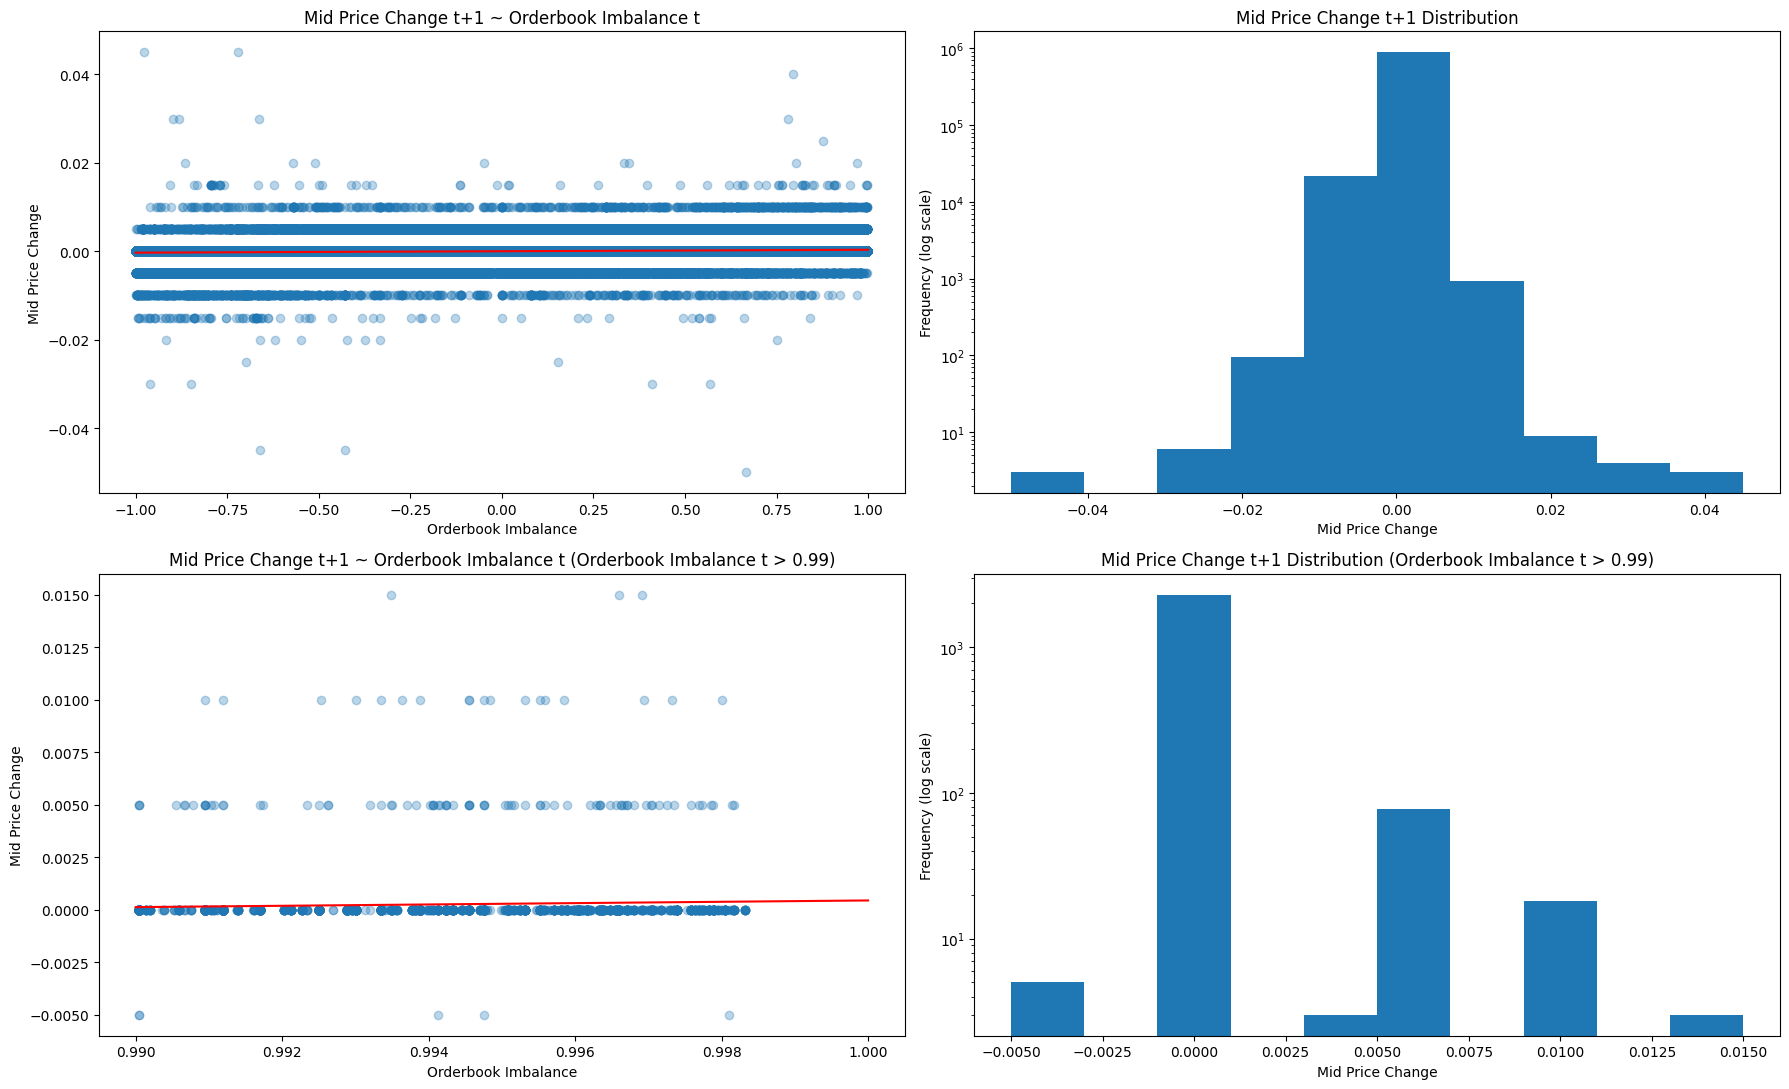

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 11))

X = merged_df.select(
    pl.col('volume_imbalance_lag_1')
).with_columns(
    constant_value=1
).to_numpy()

Y = merged_df.select(
    pl.col('national_mid_price_change_1')
).to_numpy()

B, residuals, rank, s = np.linalg.lstsq(X, Y)   # better numerical stability than directly solving normal equations (uses Singular Value Decomposition on design matrix instead of inverting matrix)
x = np.linspace(-1, 1, 1000)
y = B[0][0]*x + B[1][0]

axes[0][0].scatter(merged_df['volume_imbalance_lag_1'], merged_df['national_mid_price_change_1'], alpha=0.3)
axes[0][0].plot(x, y, color='red')
axes[0][0].set_title('Mid Price Change t+1 ~ Orderbook Imbalance t')
axes[0][0].set_xlabel('Orderbook Imbalance')
axes[0][0].set_ylabel('Mid Price Change')

axes[0][1].hist(merged_df['national_mid_price_change_1'])
axes[0][1].set_yscale('log')
axes[0][1].set_title('Mid Price Change t+1 Distribution')
axes[0][1].set_xlabel('Mid Price Change')
axes[0][1].set_ylabel('Frequency (log scale)')

filter_imbalance_df = merged_df.filter(
    pl.col('volume_imbalance_lag_1') > 0.99
)

X = filter_imbalance_df.select(
    pl.col('volume_imbalance_lag_1')
).with_columns(
    constant_value=1
).to_numpy()

Y = filter_imbalance_df.select(
    pl.col('national_mid_price_change_1')
).to_numpy()

B, residuals, rank, s = np.linalg.lstsq(X, Y)   # better numerical stability than directly solving normal equations (uses Singular Value Decomposition on design matrix instead of inverting matrix)
x = np.linspace(0.99, 1, 1000)
y = B[0][0]*x + B[1][0]

axes[1][0].scatter(filter_imbalance_df['volume_imbalance_lag_1'], filter_imbalance_df['national_mid_price_change_1'], alpha=0.3)
axes[1][0].plot(x, y, color='red')
axes[1][0].set_title('Mid Price Change t+1 ~ Orderbook Imbalance t (Orderbook Imbalance t > 0.99)')
axes[1][0].set_xlabel('Orderbook Imbalance')
axes[1][0].set_ylabel('Mid Price Change')

axes[1][1].hist(filter_imbalance_df['national_mid_price_change_1'])
axes[1][1].set_yscale('log')
axes[1][1].set_title('Mid Price Change t+1 Distribution (Orderbook Imbalance t > 0.99)')
axes[1][1].set_xlabel('Mid Price Change')
axes[1][1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

### Backtest Strategy
1. When orderbook imbalance > 0.99, buy at ask price
2. When bid price changes, sell at bid price

In [18]:
last_bid_price = -1
buy_price = -1
sell_price = -1
buy_time = -1
sell_time = -1
total_profit = 0
trade_active = False

trade_list = []

book = LimitOrderBook() # initialize a new limit order book object 

for order in market_by_order_data_df.iter_rows(named=True):
    # apply order to the limit order book
    book.apply_order(order)

    # get the best bid price and best bid size
    national_best_bid_price, national_best_bid_size = book.get_best_bid()

    # get the best ask price and best ask size
    national_best_ask_price, national_best_ask_size = book.get_best_ask()

    # calculate the top of book volume imbalance
    if national_best_bid_size+national_best_ask_size>0:
        orderbook_imbalance = (national_best_bid_size-national_best_ask_size)/(national_best_bid_size+national_best_ask_size)

        if orderbook_imbalance > 0.99 and not trade_active:
            buy_time = order['ts_recv_int']
            last_bid_price = national_best_bid_price
            buy_price = national_best_ask_price

            trade_active = True

        if not math.isclose(national_best_bid_price, last_bid_price, abs_tol=0.001) and trade_active:
            sell_price = national_best_bid_price
            sell_time = order['ts_recv_int']
            profit = sell_price - buy_price
            total_profit += profit 

            trade_list.append({
                'buy_time': buy_time, 
                'sell_time': sell_time, 
                'buy_price': buy_price, 
                'sell_price': sell_price,
                'profit': profit
            })

            last_bid_price = -1
            buy_price = -1
            sell_price = -1
            buy_time = -1
            sell_time = -1

            trade_active = False

df = pl.DataFrame(trade_list)
df = df.with_columns(
    buy_time_timestamp=pl.col('buy_time').cast(pl.Datetime('ns')).dt.replace_time_zone('UTC').dt.convert_time_zone('America/New_York'),
    sell_time_timestamp=pl.col('sell_time').cast(pl.Datetime('ns')).dt.replace_time_zone('UTC').dt.convert_time_zone('America/New_York')
).sort(
    pl.col('profit'), descending=True
)

# orderbook imbalance > 0.99
df.group_by(
    pl.col('profit').round(2)
).len().sort('profit', descending=True)

profit,len
f64,u32
0.0,40
-0.01,49
-0.02,30
-0.03,15
-0.04,2
-0.05,1
